# Глава 6. Модель Хольта-Винтерса (тройное экспоненциальное сглаживание, ETS)

## 1. Теория

### 1.1 Экспоненциальное сглаживание

**Экспоненциальное сглаживание** — прогноз как взвешенное среднее прошлых значений, где вес **экспоненциально убывает** с давностью: вчера весит больше, чем позавчера, позавчера — больше, чем неделю назад, и так далее. Насколько быстро модель «забывает» прошлое, задаёт коэффициент сглаживания $\large \alpha$ от 0 до 1.

#### Из каких частей модель собирает прогноз
- Представляем каждое значение ряда как сумму (или произведение) нескольких понятных компонент. Пример — заказы юнита за неделю: пн=200, вт=210, ср=220, чт=230, пт=300, сб=340, вс=250. Тогда компоненты будут:
	- **Уровень** $\large \ell$ — «сколько обычно» у ряда **сейчас**, если убрать день недели и случайный шум. Здесь это 250 заказов в день (среднее за неделю: 1750 / 7). Значит, «юнит сейчас живёт на 250 заказов в день». Это одно число на каждый момент времени, и оно медленно сдвигается по мере прихода новых данных.
	- **Тренд** $\large b$ — **наклон** уровня: на сколько уровень меняется за один шаг. Если через месяц типичный день стал 280 вместо 250, уровень рос примерно на +1 в день — это и есть тренд. Тренд нет смысла считать без уровня: он отвечает не на вопрос «где ряд», а на вопрос «куда и как быстро он движется».
	- **Сезонность** $\large I$ — повторяющаяся **поправка** к уровню для конкретной точки цикла, то есть отклонение факта от уровня. Насколько конкретный день недели отличается от типичного? Считаем как: факт − уровень ("типичный день"). Например:
		- понедельник: 200 − 250 = −50, на 50 меньше обычного
		- пятница: 300 − 250 = +50, на 50 больше обычного
	- **Шум** — всё, что осталось: дождь в среду дал +15, сбой доставки в четверг −20. Модель его не объясняет и не прогнозирует.
- **Прогноз** = **Уровень** + (**Тренд** × **Шаги вперёд**) + **Сезонность**. Например, прогноз на пятницу через $\large m$ дней: $\large 250 + (1 \cdot m) + 50$.

### 1.2 Семейство моделей строится по мере добавления компонент:

- **Простое экспоненциальное сглаживание** `SimpleExpSmoothingModel` — используется, когда нет тренда и сезонности, только «шум» вокруг среднего уровня. Прогноз на любой шаг вперёд — последний уровень, горизонтальная линия: $$\LARGE F_{t+m} = \ell_t$$
  Уровень обновляется на каждом шаге обучения: $$\LARGE \ell_t = \alpha Y_t + (1 - \alpha)\ell_{t-1}$$

- **Двойное экспоненциальное сглаживание (метод Хольта)** `HoltModel` — используется, когда ряд **имеет тренд**: простое сглаживание будет постоянно отставать от растущего ряда. Поэтому Хольт добавил второй слой сглаживания — для тренда. Прогноз — наклонная прямая от последнего уровня: $$\LARGE F_{t+m} = \ell_t + m\,b_t$$
  Уровень и тренд обновляются на каждом шаге обучения: $$\LARGE
    \begin{cases}
       \ell_t = \alpha Y_t + (1 - \alpha)(\ell_{t-1} + b_{t-1}) \\
       b_t = \beta (\ell_t - \ell_{t-1}) + (1 - \beta)b_{t-1}
    \end{cases}
$$

- **Тройное экспоненциальное сглаживание (модель Хольта-Винтерса)** `HoltWintersModel` — используется, когда ряд **имеет и тренд, и сезонность**. Добавляется третий компонент — сезонный индекс. Прогноз — наклонная прямая с наложенным сезонным узором. Вариант с аддитивным трендом и аддитивной сезонностью: $$\LARGE F_{t+m} = \ell_t + m\,b_t + I_{t-L+1+(m-1)}$$
  То есть: последний уровень + наклон × число шагов вперёд + сезонная поправка для этой точки цикла из последнего полного цикла. Индекс $\large t-L+1+(m-1)$ — это то же самое, что $\large t+m-L$.
  Уровень, тренд и сезонный индекс обновляются на каждом шаге обучения: $$\LARGE
    \begin{cases}
       \ell_t = \alpha (Y_t - I_{t-L}) + (1 - \alpha)(\ell_{t-1} + b_{t-1}) \\
       b_t = \beta (\ell_t - \ell_{t-1}) + (1 - \beta)b_{t-1} \\
       I_t = \gamma (Y_t - \ell_{t-1} - b_{t-1}) + (1 - \gamma)I_{t-L}
    \end{cases}
$$

где (обозначения общие для всех трёх моделей):
- $\large Y_{t}$ — фактическое значение ряда в момент времени $\large t$.
- $\large \ell_{t}$ — **уровень** в момент $\large t$: «где сейчас ряд», очищенный от сезонности и шума. В простом сглаживании уровень и есть прогноз.
- $\large b_{t}$ — **тренд** в момент $\large t$: на сколько уровень меняется за один шаг (наклон). Считается как сглаженная разница соседних уровней $\large \ell_t - \ell_{t-1}$.
- $\large I_{t}$ — **сезонный индекс** в момент $\large t$: поправка для этой точки цикла (например, «пятница — на 50 заказов выше уровня»).
- $\large L$ — длина сезонного цикла, `seasonal_periods` (7 для недельной сезонности на дневных данных); $\large I_{t-L}$ — индекс той же точки цикла в прошлом цикле.
- $\large m$ — на сколько шагов вперёд строится прогноз.
- $\large F_{t+m}$ — прогноз на момент $\large t+m$.
- $\large \alpha, \beta, \gamma \in [0, 1]$ — коэффициенты сглаживания уровня, тренда и сезонности (`smoothing_level` / `smoothing_trend` / `smoothing_seasonal`). Смысл у всех одинаковый:
    - близко к 1 — сглаживание **слабое**: компонента быстро подстраивается под свежие данные и быстро «забывает» прошлое;
    - близко к 0 — сглаживание **сильное**: компонента меняется медленно и дольше «помнит» прошлое;
    - для $\large \beta$: около 0 — наклон почти постоянный, около 1 — наклон пересчитывается по последним точкам;
    - для $\large \gamma$: около 0 — недельный узор почти не меняется со временем, около 1 — узор каждую неделю переписывается по последней неделе.


#### Отличие от
- `SeasonalMovingAverageModel` тоже прогнозирует «тем же днём прошлых недель», но берёт `window` последних сезонов с **равными** весами и не знает про тренд. Хольт-Винтерс отдельно ведёт уровень, тренд и сезонный узор, и веса у прошлых наблюдений **экспоненциально убывают**.
- `SARIMAXModel` сначала делает ряд стационарным (`d`/`D`) и моделирует корреляции между точками. Хольт-Винтерс раскладывает ряд на понятные компоненты — уровень, тренд, сезонность — и **не требует стационарности**: тренд и сезонность здесь не убираются, а прямо моделируются. Поэтому никаких `adfuller` и ACF/PACF перед запуском не нужно.

### 1.3 Таксономия: какие бывают тренд и сезонность.

Конкретная формула модели определяется двумя вопросами: **как меняется уровень** (тип тренда) и **как сезонная волна связана с уровнем** (тип сезонности). Все формулы из пособия — это таблица «тип тренда × тип сезонности», и каждая клетка — своя модель. Аддитивный вариант строится через «плюс», мультипликативный — через «умножить».

**Тренд — как меняется уровень со временем:**
- **Без тренда** — ряд колеблется вокруг постоянного уровня. Прогноз — горизонтальная линия (плюс сезонность).
- **Аддитивный** — уровень меняется на **одинаковое число единиц** за шаг: «+5 заказов в день». На графике — прямая линия. В формулах: $\large \ell_t + m\,b_t$.
- **Аддитивный с затуханием** — то же, но рост постепенно **замедляется и выходит на плато**: каждый следующий шаг добавляет долю $\large \phi$ (от 0 до 1) от предыдущего прироста. Реалистичнее на длинном горизонте: обычный тренд — бесконечная прямая, которая рано или поздно уйдёт в небо или в ноль.
- **Мультипликативный** — уровень меняется на **одинаковый процент** за шаг: «+2% в день». На графике — кривая, которая ускоряется (экспонента). В формулах: $\large \ell_t \cdot b_t^m$, где $\large b_t$ — коэффициент роста около 1.
- **Мультипликативный с затуханием** — процентный рост, который постепенно гаснет.

**Сезонность — как сезонная волна связана с уровнем:**
- **Без сезонности** — повторяющегося узора нет.
- **Аддитивная** — сезонная поправка в **штуках**: «в пятницу на 50 заказов больше уровня». **Размах волны постоянный** и не зависит от уровня: при уровне 200 и при уровне 400 пятница всё так же «+50». Индекс $\large I$ — число около 0, за цикл поправки в сумме дают ≈ 0. В формулах: $\large \ldots + I$.
- **Мультипликативная** — сезонная поправка в **разах**: «в пятницу в 1.3 раза больше уровня». **Размах волны растёт вместе с уровнем**: при уровне 200 пятница «+60», при уровне 400 уже «+120». Индекс $\large I$ — коэффициент около 1, в среднем за цикл ≈ 1. В формулах: $\large (\ldots) \cdot I$. Работает только на строго положительных данных.



### 1.4 Параметры и реализация

Исходник `etna/models/holt_winters.py`, класс `HoltWintersModel` (сигнатура сокращена):

```python
class HoltWintersModel(PerSegmentModelMixin, ...):
    def __init__(
        self,
        trend: Optional[str] = None,
        damped_trend: bool = False,
        seasonal: Optional[str] = None,
        seasonal_periods: Optional[int] = None,
        initialization_method: str = "estimated",
        use_boxcox: Union[bool, str, float] = False,
        smoothing_level: Optional[float] = None,
        smoothing_trend: Optional[float] = None,
        smoothing_seasonal: Optional[float] = None,
        damping_trend: Optional[float] = None,
        ...
    ):
```

**Параметры `HoltWintersModel`:**
- `trend` *(по умолчанию `None`)* — тип тренда: `None`, `"add"`/`"additive"`, `"mul"`/`"multiplicative"`.
- `damped_trend` *(по умолчанию `False`)* — затухающий тренд: наклон постепенно гасится с горизонтом (сила затухания — `damping_trend`, $\phi$).
- `seasonal` *(по умолчанию `None`)* — тип сезонности: `None`, `"add"`, `"mul"`.
- `seasonal_periods` — длина сезонного цикла $L$: `7` для недельной сезонности на дневных данных, `12` — для годовой на месячных. Обязателен, если задан `seasonal`.
- `smoothing_level` / `smoothing_trend` / `smoothing_seasonal` — коэффициенты $\alpha$ / $\beta$ / $\gamma$. **По умолчанию `None` — оцениваются в `fit()` оптимизацией** (минимизация ошибки на train); если задать числом — фиксируются руками.
- `initialization_method` *(по умолчанию `"estimated"`)* — как получить стартовые $\ell_0$, $b_0$, $I_{1..L}$: оценить вместе с коэффициентами или эвристикой по первым циклам.
- `use_boxcox` — преобразование Бокса-Кокса перед сглаживанием (`True`, `"log"` или число $\lambda$), стабилизирует разброс.

**Младшие модели семейства** — тот же движок, урезанный набор параметров:
- `SimpleExpSmoothingModel(smoothing_level=...)` — только уровень;
- `HoltModel(exponential=False, damped_trend=False, smoothing_level=..., smoothing_trend=..., ...)` — уровень + тренд.

**Под капотом и в сравнении с `SARIMAXModel`:**
- внутри — `statsmodels.tsa.holtwinters.ExponentialSmoothing`, отдельная модель на каждый сегмент (`PerSegmentModelMixin`), как у SARIMAX;
- API тот же: `model.fit(train_ts)` → `train_ts.make_future(HORIZON)` → `model.forecast(future_ts)`, без `tail_steps`/`prediction_size`;
- экзогенные регрессоры **не поддерживаются** — только сам ряд;
- `model.get_model()` → `{segment: HoltWintersResultsWrapper}`: подобранные коэффициенты в `.params` (`smoothing_level`, `smoothing_trend`, `smoothing_seasonal`, ...), сами компоненты в `.level`, `.trend`, `.season`, сглаженные значения — `.fittedvalues`;
- `model.forecast(future_ts, return_components=True)` — помимо прогноза отдаёт его разложение на компоненты `target_component_level` / `..._trend` / `..._seasonality`.

## 2. Данные

Те же файлы, что и в предыдущих тетрадях (`local/data/`, в `.gitignore`):
- `units.csv` — 10 юнитов; для основной практики берём 2 из них (размер `10+`, typical + busier), для бонуса — все 10.
- `facts-by-date.csv` — дневные факты, 2022-01-01…2026-08-31.

Период и сплит — как в прошлых тетрадях: с 2026-04-01, test — последние 14 дней (2026-08-18 … 2026-08-31). Тогда результаты сравнимы с `NaiveModel` / `MovingAverageModel` / `SeasonalMovingAverageModel` / `SARIMAXModel` напрямую, в том числе в MLflow.

В этой главе не сравниваем с продовым прогнозом (`forecasts-by-date.csv`) — это отдельная тема, которой займёшься сам.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing

from etna.datasets import TSDataset
from etna.models import HoltWintersModel, HoltModel, SimpleExpSmoothingModel, SARIMAXModel
from etna.metrics import SMAPE, WAPE, MAPE, MAE
from etna.analysis import plot_forecast

from src.custom_logger import log_to_mlflow
from src.prod_metrics import bias, pooled

DATA_DIR = "../../local/data"
HORIZON = 14

/Users/skv/projects-skv/study-etna/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Практика

От простого к сложному: сначала на синтетике проходим всё семейство — уровень → тренд → сезонность — и разбираем прогноз руками по формуле, потом сравниваем аддитивную и мультипликативную сезонность, и только после этого переходим к реальным юнитам и сравнению с SARIMAX.

### Задание 1. Синтетика: уровень → тренд → сезонность

1. Собери синтетический ряд с **трендом и недельной сезонностью** и немного шума — так же, как в тетради про SARIMAX (линейный тренд + недельный паттерн + `np.random.normal`), только подлиннее, например 10–12 недель. Оберни его в `TSDataset` с одним сегментом (`segment="synthetic"`).
2. Раздели на train/test, test — последние 14 дней.
3. Обучи по очереди три модели с коэффициентами по умолчанию (подбираются сами): `SimpleExpSmoothingModel()`, `HoltModel()`, `HoltWintersModel(trend="add", seasonal="add", seasonal_periods=7)`.
4. Нарисуй все три прогноза на одном графике (`plot_forecast` принимает словарь `{имя: forecast_ts}`) и посчитай SMAPE каждого.
5. Объясни форму каждого прогноза по разделу 1.2: почему у первой модели горизонтальная линия, у второй — наклонная, у третьей — наклонная «пила»? Какая компонента ряда каждый раз «не помещается» в модель?

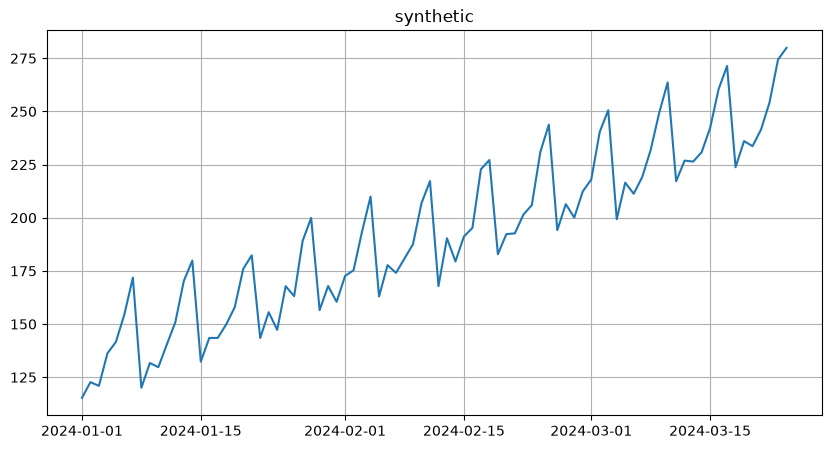

In [16]:
# Синтетика: тренд + недельная сезонность + немного шума
np.random.seed(0)
periods = 84  # 12 недель

day_of_week_pattern = np.array([10, 20, 15, 25, 30, 50, 60], dtype=float)
seasonal = np.tile(day_of_week_pattern, periods // 7 + 1)[:periods]
trend = np.arange(periods) * 1.5
noise = np.random.normal(0, 3, periods)

df = pd.DataFrame({
    "timestamp": pd.date_range("2024-01-01", periods=periods, freq="D"),
    "segment": "synthetic",
    "target": seasonal + trend + 100 + noise,
})

ts = TSDataset(df=df, freq="D")
ts.plot();

In [105]:
train_ts, test_ts = ts.train_test_split(test_size=14)

errors = {}

In [106]:
# Простое экспоненциальное сглаживание
model_simple = SimpleExpSmoothingModel()
model_simple.fit(train_ts)
future_simple = train_ts.make_future(future_steps=HORIZON)
forecast_simplt = model_simple.forecast(future_simple)
errors["simple"] = SMAPE()(y_true=test_ts, y_pred=forecast_simplt)
# model_triple

In [107]:
# Двойное экспоненциальное сглаживание
model_double = HoltModel()
model_double.fit(train_ts)
future_double = train_ts.make_future(future_steps=HORIZON)
forecast_double = model_double.forecast(future_double)
errors["double"] = SMAPE()(y_true=test_ts, y_pred=forecast_double)

In [108]:
# Тройное экспоненциальное сглаживание
# HoltWintersModel() без параметров по умолчанию собирается с trend=None, seasonal=None и это будет обычный SimpleExpSmoothingModel()
model_triple = HoltWintersModel(trend="add", seasonal="add", seasonal_periods=7)
model_triple.fit(train_ts)
future_triple = train_ts.make_future(future_steps=HORIZON)
forecast_triple = model_triple.forecast(future_triple)
errors["triple"] = SMAPE()(y_true=test_ts, y_pred=forecast_triple)

{'simple': {'synthetic': 6.6510059030156095},
 'double': {'synthetic': 5.820375715534911},
 'triple': {'synthetic': 1.0147928392773}}

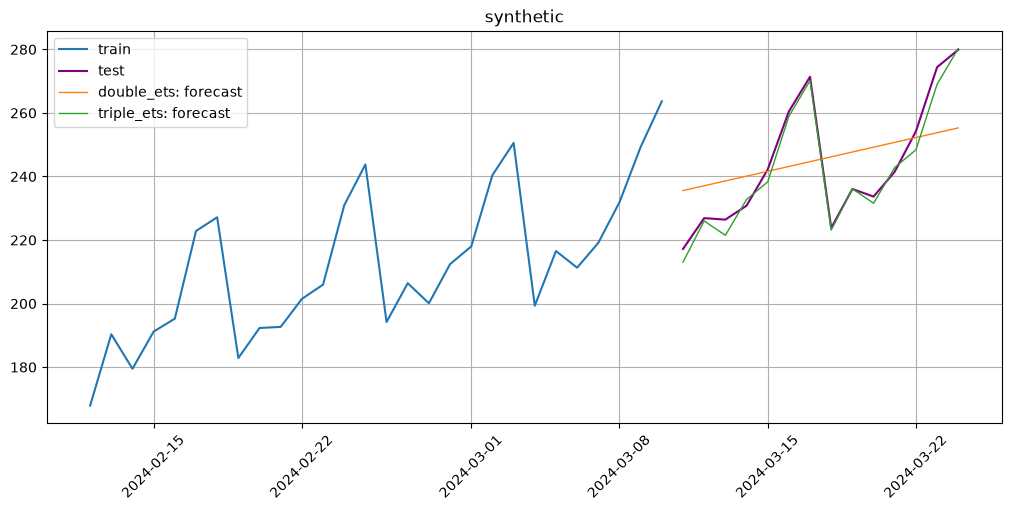

In [109]:
plot_forecast(
    forecast_ts={
        # "simple_ets" : forecast_simplt,
        "double_ets": forecast_double,
        "triple_ets": forecast_triple,
    },
    test_ts=test_ts,
    train_ts=train_ts,
    n_train_samples=4 * 7,
)
errors

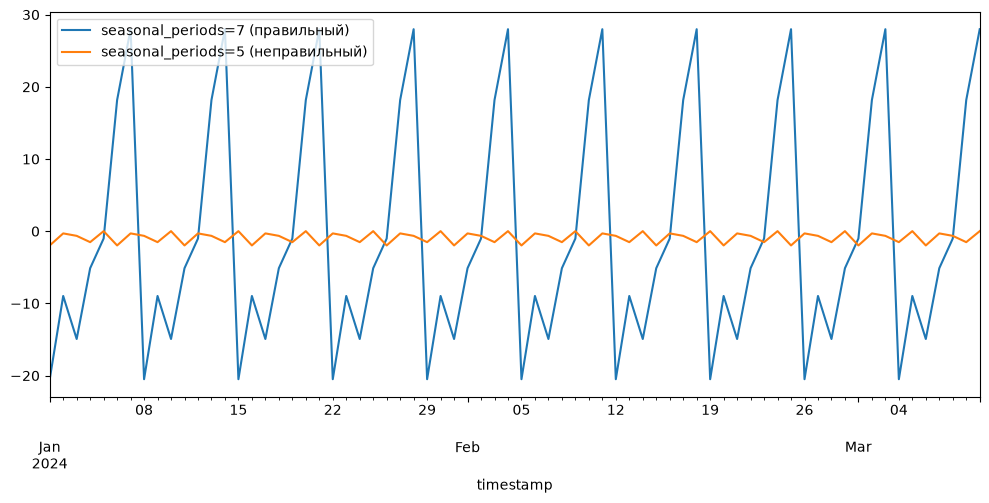

In [104]:
# Тройное экспоненциальное сглаживание с НЕПРАВИЛЬНЫМ периодом: seasonal_periods=5 вместо 7
model_triple_error = HoltWintersModel(trend="add", seasonal="add", seasonal_periods=5)
model_triple_error.fit(train_ts)
future_triple_error = train_ts.make_future(future_steps=HORIZON)
forecast_triple_error = model_triple_error.forecast(future_triple_error)
errors["triple_error"] = SMAPE()(y_true=test_ts, y_pred=forecast_triple_error)

# Почему прогноз получается почти как у Хольта (двойного сглаживания)?

# Модель заводит 5 сезонных поправок — по одной на каждую позицию «цикла из 5 дней» — и считает, что позиция 1 каждый раз означает одно и то же.
# Но настоящий цикл — 7 дней, поэтому позиция 1 каждый цикл приходится на РАЗНЫЙ день недели: 1-й цикл → пн, 2-й → сб, 3-й → чт, 4-й → вт, ...
# Поправку для позиции 1 «тянут» то понедельник (−20), то суббота (+30), то четверг (−5) — в среднем они гасят друг друга, и поправка уходит к нулю.
# То же со всеми пятью позициями.
# Итог: сезонные поправки ≈ 0, и прогноз ℓ + m·b + I превращается в ℓ + m·b — это и есть Хольт.

# Проверка — смотрим на РАЗМЕР сезонных поправок:
#   период 7 — чёткая «пила» (≈ −20 … +28, наш недельный паттерн минус его среднее);
#   период 5 — мелкие значения около нуля, узор не найден.
ax = model_triple.get_model()["synthetic"].season.plot(
    label="seasonal_periods=7 (правильный)",
    figsize=(12, 5),
)
model_triple_error.get_model()["synthetic"].season.plot(ax=ax, label="seasonal_periods=5 (неправильный)")
ax.legend(loc="upper left");

### Задание 2. Разбираем прогноз руками

Цель — убедиться, что прогноз Хольта-Винтерса — это не чёрный ящик, а ровно формула из раздела 1.2.

1. На train из Задания 1 обучи `statsmodels`-модель напрямую — `ExponentialSmoothing(series, trend="add", seasonal="add", seasonal_periods=7, initialization_method="estimated").fit(smoothing_level=..., smoothing_trend=..., smoothing_seasonal=...)` — с **фиксированными** коэффициентами (например, `0.3 / 0.05 / 0.2`).
2. Собери датафрейм из факта `y`, уровня `.level`, тренда `.trend`, сезонности `.season` и сглаженных значений `.fittedvalues`. Посмотри на последние строки — как ведут себя уровень, тренд и сезонность от шага к шагу? (Колонки лучше назвать `level` / `trend` / `season`, а не `L` / `B` / `S`, как в пособии: у нас $L$ — длина цикла.)
3. Посчитай руками прогноз на 1 и 2 шага вперёд по формуле $F_{t+m} = \ell_t + m\,b_t + I_{t-L+1+(m-1)}$ и сравни с `.forecast(HORIZON)` — должны совпасть.
4. Обучи `HoltWintersModel` из ETNA с теми же фиксированными коэффициентами и сравни его прогноз с прогнозом `statsmodels` — совпадают? (раздел 1.4: что лежит под капотом).
5. Получи прогноз ETNA с `return_components=True` и посмотри на компоненты `level` / `trend` / `seasonality`: их сумма должна давать `target`.

### Задание 3. Синтетика: аддитивная vs мультипликативная сезонность

1. Собери второй синтетический ряд, где **амплитуда недельной волны растёт вместе с уровнем**: не `тренд + паттерн`, а `тренд × (1 + паттерн)` (паттерн — доли, например от `-0.3` до `+0.4`). Построй его рядом с рядом из Задания 1 — увидь, как «пила» расширяется.
2. На обоих рядах обучи `HoltWintersModel(..., seasonal="add")` и `HoltWintersModel(..., seasonal="mul")`, сравни SMAPE — получится таблица 2 × 2 (ряд × тип сезонности).
   > Клетка таксономии из раздела 1.3 выбирается в `HoltWintersModel` тремя параметрами: `trend=None / "add" / "mul"` (тип тренда), `damped_trend=True` (затухание), `seasonal=None / "add" / "mul"` (тип сезонности). Здесь меняем только `seasonal`, остальное держим одинаковым (`trend="add"`, `seasonal_periods=7`).
   >
   > `seasonal="mul"` работает только на **строго положительных** данных — синтетику собирай так, чтобы она не уходила в ноль и ниже.
3. Какой тип сезонности выигрывает на каком ряде? Насколько велика разница — сильно ли ошибается «неправильный» тип?
4. Посмотри на подобранные коэффициенты (`model.get_model()["synthetic"].params`) для правильной и неправильной модели — заметно ли, что неправильная пытается компенсировать несоответствие (например, большим $\gamma$)?

### Задание 4. Загрузи данные по 2 юнитам размера `10+`

1. Прочитай `facts-by-date.csv` и `units.csv`, оставь только 2 юнита размера `10+` (typical + busier) — так же, как для предыдущих моделей, с 2026-04-01.
2. Собери `TSDataset` (дневная частота), где `segment` = `MaskedUnitId`.
3. Посмотри на `ts.describe()`.
4. Построй `ts.plot()` и ответь глазами на три вопроса — от них зависит, какую клетку таксономии (раздел 1.3) брать в Задании 5:
   - **Есть ли тренд?** Линия уровня прямая и идёт вверх/вниз → аддитивный (`trend="add"`); загибается вверх → мультипликативный (`"mul"`); рост замедляется → с затуханием (`damped_trend=True`); направления нет → без тренда (`trend=None`).
   - **Есть ли сезонность и с каким периодом?** Повторяющаяся «пила» с шагом в неделю → `seasonal_periods=7`.
   - **Add или mul?** «Пила» одной ширины по всему ряду → `seasonal="add"`; расширяется по мере роста ряда → `seasonal="mul"`.
5. Раздели на train/test (последние `HORIZON` = 14 дней).

### Задание 5. Подбираем конфигурацию на двух юнитах

1. Обучи сразу на обоих сегментах несколько конфигураций, от простого к сложному (коэффициенты — по умолчанию, подбираются в `fit()`):
   - `SimpleExpSmoothingModel()` и `HoltModel()` — как точка отсчёта без сезонности;
   - `HoltWintersModel(trend=None, seasonal="add", seasonal_periods=7)` — сезонность без тренда;
   - `HoltWintersModel(trend="add", seasonal="add", seasonal_periods=7)`;
   - `HoltWintersModel(trend="add", seasonal="mul", seasonal_periods=7)`;
   - `HoltWintersModel(trend="add", damped_trend=True, seasonal="add", seasonal_periods=7)` — затухающий тренд: обычный аддитивный тренд — бесконечная прямая, на длинном горизонте прогноз может уйти в небо или в ноль, а затухание гасит наклон с каждым шагом. На 14 днях разница может быть небольшой.
2. Посчитай `SMAPE` — per-segment и `mode="macro"`, собери в одну таблицу (строки — конфигурации, колонки — юниты + macro).
3. Для лучшей конфигурации посмотри подобранные $\alpha$ / $\beta$ / $\gamma$ по каждому юниту (`get_model()[segment].params["smoothing_level"]` / `["smoothing_trend"]` / `["smoothing_seasonal"]`) и интерпретируй их (смысл коэффициентов — в разделе 1.2):
   - $\alpha$ близко к 1 — уровень сильно скачет, модель гонится за последними точками; близко к 0 — уровень стабильный, модель усредняет по длинной истории;
   - $\beta \approx 0$ — наклон почти не меняется (или тренда по сути нет);
   - $\gamma \approx 0$ — недельный узор фактически не обновляется, модель считает его постоянным; ближе к 1 — узор заметно меняется от недели к неделе.

   Насколько модель доверяет последним точкам? Обновляется ли недельный узор? Одинаково ли это у двух юнитов?
4. Попробуй ту же лучшую конфигурацию с **фиксированными** коэффициентами, как в пособии (например, `0.1 / 0.1 / 0.1`), — лучше или хуже, чем автоподбор?
5. Визуализируй лучшую конфигурацию через `plot_forecast` и разложи её прогноз на компоненты (`return_components=True`).

### Задание 6. Сравнение с SARIMAX и предыдущими моделями

1. На тех же 2 юнитах и том же сплите сравни лучшую конфигурацию Хольта-Винтерса с лучшим SARIMAX из прошлой тетради (`SARIMAXModel(order=(0,0,1), seasonal_order=(1,1,0,7))`, `smape_macro` 7.42) — можно просто обучить его здесь же.
2. Сравни per-segment: на каком юните какая модель лучше? Совпадает ли это с тем, насколько у юнита ровный недельный узор?
3. Сделай вывод: оправдывает ли Хольт-Винтерс себя по сравнению с SARIMAX, если учесть, что для него не нужны ни `adfuller`, ни ACF/PACF, а выбор сводится к «тренд? сезонность? add/mul?».

### Бонус. Общая картина по всем 10 юнитам + логирование

1. Прогони 2–3 лучшие конфигурации из Задания 5 сразу на всех 10 юнитах (используй `orders_df` из Задания 4 без фильтра по `unit_size`).
2. Посчитай весь набор метрик — `SMAPE`, `WAPE`, `MAPE`, `MAE`, `Bias` (через `src/prod_metrics.py`), per-segment и агрегированно.
3. Собери всё в одну таблицу `result` (`segment`/`unit_size`/`pick_reason`/`total_orders` + подобранные $\alpha$ / $\beta$ / $\gamma$ + все метрики) — подобранные коэффициенты по юнитам покажут, насколько разные у них паттерны.
4. Залогируй каждую конфигурацию отдельным запуском через `log_to_mlflow(...)` — по аналогии с бонусом SARIMAX:
   - имя запуска: `HoltWinters_<вариант>_ch06_all_10_day`, например `HoltWinters_add_add_ch06_all_10_day`;
   - теги: `{"chapter": "ch06", "units_scope": "all_10", "granularity": "day", "model_family": "ets", "impl": "statsmodels"}` + свой тег варианта (например, `"trend": "add"`, `"seasonal": "mul"`, `"damped": "true"`);
   - тогда в MLflow запуски Хольта-Винтерса встанут рядом с `NaiveModel` / `MovingAverageModel` / `SeasonalMovingAverageModel` / `SARIMAX_*` в одной таблице.